## Bias amplification

In [26]:
from graphviz import Digraph
from IPython.display import Image, display
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from tqdm import trange
import scipy.stats as stats
# Density estimation
from scipy.stats import gaussian_kde

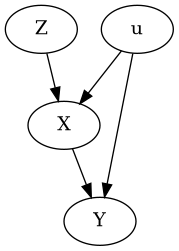

In [21]:
dot = Digraph()

dot.node('Z')
dot.node('X')
dot.node('Y')
dot.node('u')

dot.edges([('Z', 'X'), ('u', 'X'), ('u', 'Y'), ('X', 'Y')])

png = dot.pipe(format='png')
display(Image(png))

We want to model X > Y but confounder u affects both and also Z affects X. When you control for \( Z \):

- You're reducing the variance in \( X \) that is explained by \( Z \), leaving more variance in \( X \) explained by \( u \).
- That means the **relative influence of \( u \) on \( X \)** increases.
- Now, when you regress \( Y \sim X + Z \), the **spurious correlation** between \( X \) and \( Y \) driven by \( u \) becomes stronger, because:
  - \( Z \) "soaks up" the innocent part of \( X \)'s variance,
  - leaving the **guilty part** (due to \( u \)) more dominant.

This is sometimes called **bias amplification**: controlling for an instrument (or proxy) like \( Z \), when there's **unobserved confounding**, makes the confounding worse — not better.



In [5]:
def f(n=100, bZX=1, bXY=1):
    """when bXY=0, the true effect of X on Y is zero, but confounding from u biases both models"""
    Z = np.random.normal(size=n)
    u = np.random.normal(size=n)
    X = np.random.normal(loc=bZX * Z + u)
    Y = np.random.normal(loc=bXY * X + u)

    # Regression Y ~ X
    X1 = sm.add_constant(X)
    model1 = sm.OLS(Y, X1).fit()
    bX = model1.params[1]  # coefficient for X

    # Regression Y ~ X + Z
    X2 = sm.add_constant(np.column_stack((X, Z)))
    model2 = sm.OLS(Y, X2).fit()
    bXZ = model2.params[1]  # coefficient for X

    return bX, bXZ

In [6]:
# Simulate
n_sim = int(1e4)
results = np.array([f(bXY=0) for _ in trange(n_sim)])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:03<00:00, 3220.71it/s]


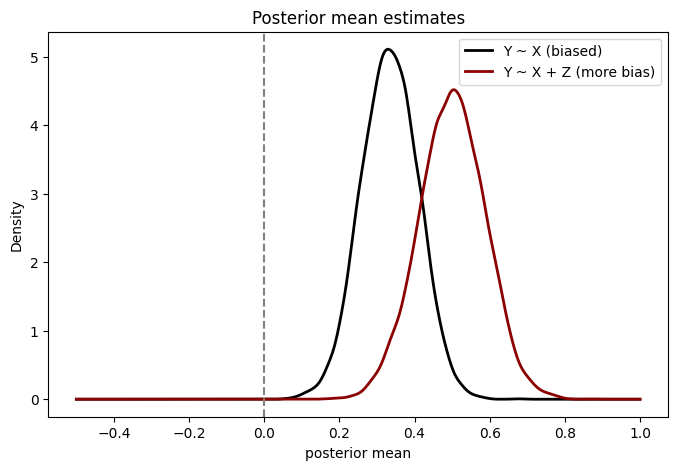

In [10]:
# Plot
plt.figure(figsize=(8, 5))
plt.title("Posterior mean estimates")
plt.xlabel("posterior mean")
plt.ylabel("Density")


kde1 = gaussian_kde(results[:, 0])
kde2 = gaussian_kde(results[:, 1])
x_vals = np.linspace(-0.5, 1, 500)

plt.plot(x_vals, kde1(x_vals), label="Y ~ X (biased)", color='black', linewidth=2)
plt.plot(x_vals, kde2(x_vals), label="Y ~ X + Z (more bias)", color='darkred', linewidth=2)
plt.axvline(0, color='gray', linestyle='dashed')
plt.legend()
plt.show()

In [34]:
n=1000
Z = np.random.binomial(n=1, p=0.5, size=n)
u = np.random.normal(size=n)
X = np.random.normal(loc=7 * Z + u)
Y = np.random.normal(loc=0*X + u)

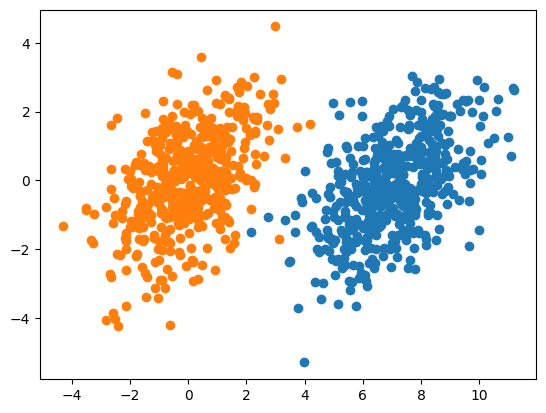

In [36]:
plt.scatter(X[Z==1], Y[Z==1])
plt.scatter(X[Z==0], Y[Z==0])

In [52]:
#lets model to see if we have controlled for Z and when we have not controlled for it
def fit_ols(X, Y):
    X_all = sm.add_constant(X)
    model = sm.OLS(Y, X_all).fit()
    return model.params

def get_model_line(model_params, min_value=-4, max_value=10):
    x_space=np.linspace(min_value, max_value)
    y_all=model_params[0]+model_params[1]*x_space
    return x_space, y_all

params_all=fit_ols(X, Y)
line_all=get_model_line(params_all)

params_0=fit_ols(X[Z==0], Y[Z==0])
line_0=get_model_line(params_0)

params_1=fit_ols(X[Z==1], Y[Z==1])
line_1=get_model_line(params_1)

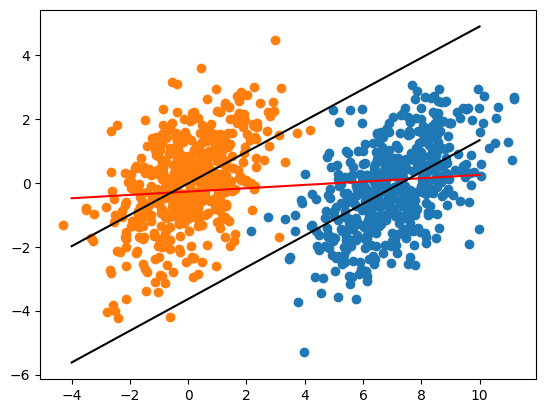

In [56]:
plt.scatter(X[Z==1], Y[Z==1])
plt.scatter(X[Z==0], Y[Z==0])
plt.plot(line_all[0], line_all[1], color='red')
plt.plot(line_0[0], line_0[1], color='black')
plt.plot(line_1[0], line_1[1], color='black')

## Precision parasite

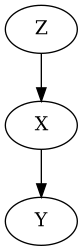

In [25]:
dot = Digraph()

# Nodes
dot.node('Z')
dot.node('X')
dot.node('Y')

# Edges: Z → X → Y
dot.edges([('Z', 'X'), ('X', 'Y')])

# Render and display as PNG
png = dot.pipe(format='png')
display(Image(png))

We want to estimate the causal effect of \( X \) on \( Y \).  
However, when we control for \( Z \), we inadvertently increase the **variance** of our estimate.  
This happens because \( Z \) partitions the data: within each level (or region) of \( Z \), there are fewer samples, making the estimate of \( X \)'s effect noisier.  

Since \( Z \) is **not a confounder** (it only affects \( X \), not \( Y \)), adjusting for it doesn't reduce bias — it only reduces **precision**.


In [22]:
def simulate(n=100, bZX=1, bXY=1):
    Z = np.random.normal(size=n)
    X = np.random.normal(loc=bZX * Z)
    Y = np.random.normal(loc=bXY * X)

    # Model 1: Y ~ X
    X1 = sm.add_constant(X)
    model1 = sm.OLS(Y, X1).fit()
    bX = model1.params[1]

    # Model 2: Y ~ X + Z
    X2 = sm.add_constant(np.column_stack((X, Z)))
    model2 = sm.OLS(Y, X2).fit()
    bXZ = model2.params[1]

    return bX, bXZ

In [23]:
# Run simulation
n_sim = int(1e4)
results = np.array([simulate(n=50) for _ in trange(n_sim)])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:02<00:00, 3610.41it/s]


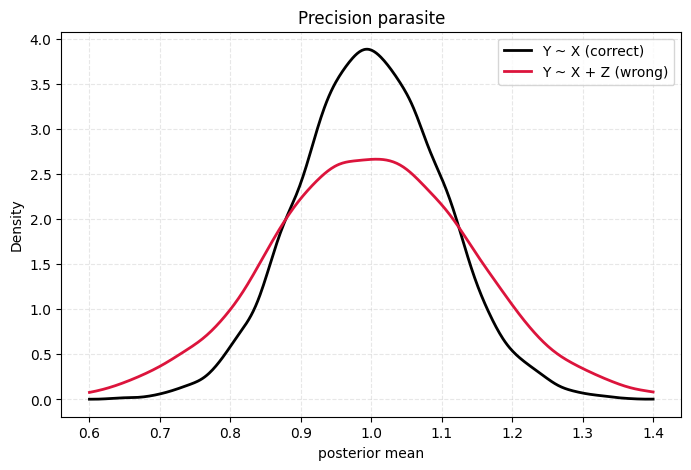

In [24]:
# Plot density
x_vals = np.linspace(0.6, 1.4, 500)
kde1 = gaussian_kde(results[:, 0])
kde2 = gaussian_kde(results[:, 1])

plt.figure(figsize=(8, 5))
plt.plot(x_vals, kde1(x_vals), label="Y ~ X (correct)", color='black', linewidth=2)
plt.plot(x_vals, kde2(x_vals), label="Y ~ X + Z (wrong)", color='crimson', linewidth=2)
plt.xlabel("posterior mean")
plt.ylabel("Density")
plt.title("Precision parasite")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()